In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


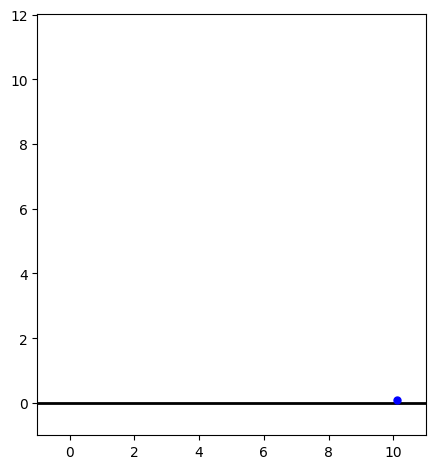

In [3]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
x_0      = 0.0    # initial x position
y_0      = 10   # initial y position
Vx_0     = .5    # initial x velocity (m/s)
Vy_0     = .2    # initial y velocity (m/s)
Gravity = 9.81   # m/s²
RestitutionRate  = 0.99   # energy retained per bounce (0=no bounce, 1=perfect bounce)
Radius  = .1    # ball radius (m)
t_final = 20    # seconds
t_step      = 0.1   # time step (s)
# ─────────────────────────────────────────────────────────────────────────────

x, y   = x_0, y_0 # Current x and y position of the ball
vx, vy = Vx_0, Vy_0 # Current x and y velocity of the ball

fig, ax = plt.subplots()
# X-limit determined by initial x, horizontal velocity, and total time
ax.set_xlim(-1, x_0 + Vx_0 * t_final + 1)
# Y-limit determined by initial y, and the maximum height reached (Vy_0**2 / (2 * Gravity) is max height due to initial upward velocity)
ax.set_ylim(-1, max(y_0, Vy_0**2 / (2 * Gravity) + y_0) + 2)
ax.axhline(0, color="black", linewidth=2)
ax.set_aspect("equal")

ball, = ax.plot(x, y, 'o', markersize=5, color="blue")

def update(frame):
    global x, y, vx, vy
    # Update vertical velocity based on gravity (kinematics equation: v = v0 + at)
    vy -= Gravity * t_step
    # Update horizontal position (kinematics equation: x = x0 + v0t)
    x  += vx * t_step
    # Update vertical position (kinematics equation: y = y0 + v0t)
    y  += vy * t_step
    # Check for collision with the ground (y <= Radius)
    if y - Radius <= 0:
        # Return to Floor
        y = Radius
        # Reverse vertical velocity and apply restitution (bounce) effect
        vy = -vy * RestitutionRate
    ball.set_data([x], [y])
    return (ball,)

anim = FuncAnimation(fig, update, frames=int(t_final / t_step), interval=t_step * 1000)
plt.tight_layout()
HTML(anim.to_jshtml())

x= 3 True
